# Clean the data

In [1]:
import os
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

load_dotenv()

engine = create_engine(os.getenv("DATABASE_URL"))

## Load the dataset

In [2]:
with engine.connect() as conn:
    df = pd.read_sql("SELECT * FROM ohlcv WHERE ticker = 'SPY'", con=conn)

## Exploration

In [3]:
df.shape

(8325, 9)

In [4]:
df.dtypes

ticker                          str
timestamp       datetime64[us, UTC]
open                        float64
high                        float64
low                         float64
close                       float64
volume                        int64
dividends                   float64
stock_splits                float64
dtype: object

In [5]:
df.tail(5)

,ticker,timestamp,open,high,low,close,volume,dividends,stock_splits
8320,SPY,2026-02-19 05:00:00+00:00,683.840027,686.179993,681.549988,684.479980,58649400,0.0,0.0
8321,SPY,2026-02-20 05:00:00+00:00,682.320007,690.059998,681.729980,689.429993,100034000,0.0,0.0
8322,SPY,2026-02-23 05:00:00+00:00,687.830017,690.000000,680.369995,682.390015,90558100,0.0,0.0
8323,SPY,2026-02-24 05:00:00+00:00,681.900024,688.349976,680.000000,687.349976,73798700,0.0,0.0
8324,SPY,2026-02-25 05:00:00+00:00,690.179993,693.679993,690.099976,693.150024,56369500,0.0,0.0


## Handle Missing Values

In [6]:
df.isnull().sum()

ticker          0
timestamp       0
open            0
high            0
low             0
close           0
volume          0
dividends       0
stock_splits    0
dtype: int64

In [7]:
df.isnull().mean() * 100

ticker          0.0
timestamp       0.0
open            0.0
high            0.0
low             0.0
close           0.0
volume          0.0
dividends       0.0
stock_splits    0.0
dtype: float64

In [8]:
df = df.drop(columns=['ticker'])

In [9]:
## Plot the data

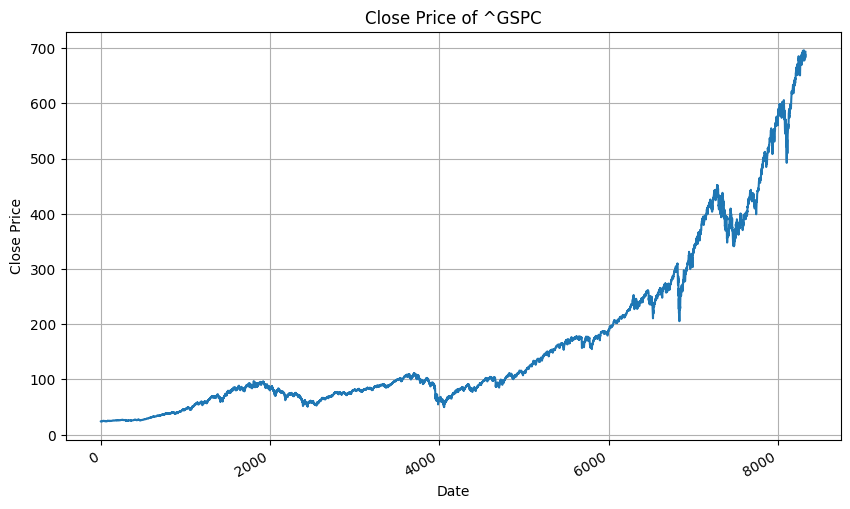

In [10]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from datetime import datetime

# df.set_index('timestamp', inplace=True)

plt.figure(figsize=(10, 6))

plt.plot(df.index, df['close'])

plt.title("Close Price of ^GSPC")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)

plt.gcf().autofmt_xdate()

plt.show()